### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [4519]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import regex as re

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [4520]:
data = pd.read_csv('data/coupons.csv')

In [4521]:
data.head(5)

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [4522]:
data.isnull().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

3. Decide what to do about your missing data -- drop, replace, other...

In [4523]:
data1 = data
data = data.dropna()
print ('Show if still space or NA in data')
print(data.isnull().sum())

Show if still space or NA in data
destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
car                     0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64


4. What proportion of the total observations chose to accept the coupon?



In [4524]:
proportion_acceptance = (data1[data1.Y == 1].shape[0])/(data1.shape[0])
print (f'proportion is {proportion_acceptance:.2%}')

proportion is 56.84%


5. Use a bar plot to visualize the `coupon` column.

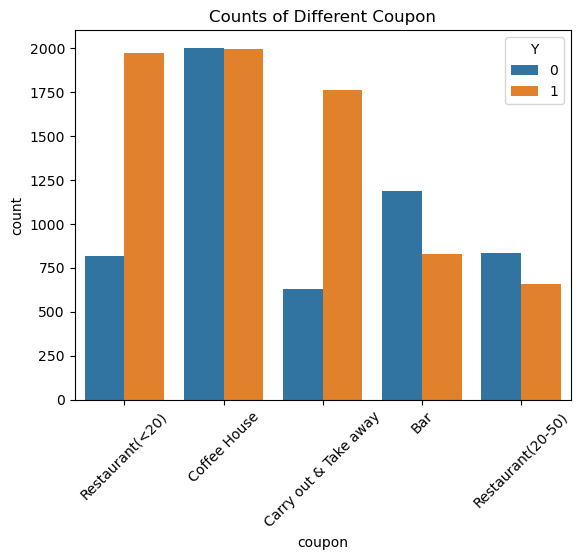

In [4525]:
# since no empty data in coupon column, use original data (data1)
#data1['coupon'].value_counts().sns.barplot(title="Couts of Different Coupon", xlabel="Coupon Types", ylabel="Counts", hue="Y")
sns.countplot(data=data1, x='coupon', hue='Y')
plt.title("Counts of Different Coupon")
plt.xticks(rotation=45)
plt.show()

6. Use a histogram to visualize the temperature column.

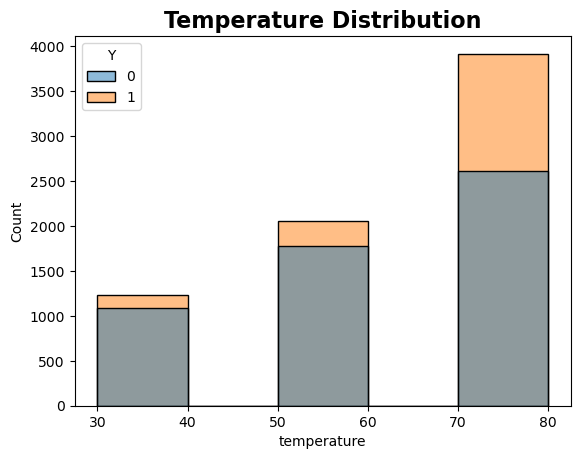

In [4526]:
# since no empty data in temperature column, use original data (data1)
sns.histplot(data=data1, x='temperature', hue='Y',bins=5)
plt.title("Temperature Distribution", fontsize=16, fontweight='bold', color='black')
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [4527]:
# # since there is no empty data in 'coupon' column, use original data (data1)
bar_df = data1[data1['coupon'] == 'Bar']
bar_df.shape[0]
#bar_df.head()


2017

2. What proportion of bar coupons were accepted?


In [4528]:
# since no gabage data in Y column. 
value = (bar_df[bar_df.Y == 1].shape[0])/(bar_df.shape[0])
print(f"Accptance Percentage is {value:.2%}")

Accptance Percentage is 41.00%


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [4529]:
#since there is garbage data in 'Bar' column, clean data in 'Bar' column in the data frame for divers use bar coupon.
data2 = bar_df.dropna(subset=['Bar'])
print (data2.shape[0])
#print(data2.isnull().sum())

# get the set of frequcies in 'Bar' column
unique_set_Bar = set(data2['Bar'])
print(f'unique_set_Bar is {unique_set_Bar}')
# Bar one time or less
bar_1nLess = []
#Bar 3 times or less
bar_3nLess = []
# Bar 4 times or more
bar_4nMore = []

# get the 'Bar' column values in groups of bar frequencies categories. 
for n in unique_set_Bar:
    n = str(n)
    if n:
        if n.endswith('1'):
            bar_1nLess.append(n)
            bar_3nLess.append(n)
        elif n.endswith('3'):
                bar_3nLess.append(n)
        elif n.endswith('1'):
            bar_1nLess.append(n)
        elif n == 'never':
            bar_1nLess.append(n)
            bar_3nLess.append(n)
        elif n == '4~8':
            bar_4nMore.append(n)
        else:
            bar_4nMore.append(n)     
print (f'bar 1time and less in column Bar list is {bar_1nLess}')
print (f'bar 3 times and less in column Bar list is {bar_3nLess}')
print (f'bar 4 times and more in column Bar list is {bar_4nMore}')

# use 'Bar' column clearn data (data2), to slice the data frame of bar > 3times and bar <=3 times. Get the length of these 2 categories, 
# And divided the clean data length with 'Bar' column clean.
bar_less_rate = ((data2.loc[data2['Bar'].isin(bar_3nLess)& (data2.Y == 1)]).shape[0])/((data2.loc[data2['Bar'].isin(bar_3nLess)]).shape[0])
bar_more_rate = ((data2.loc[data2['Bar'].isin(bar_4nMore)& (data2.Y == 1)]).shape[0])/((data2.loc[data2['Bar'].isin(bar_4nMore)]).shape[0])
print (f'Bar frequency unique set is {unique_set_Bar}')
print (f'go to bar 3 or fewer times and use coupon rate is {bar_less_rate:.2%}')
print (f'go to bar more than 3 times and use coupon rate is {bar_more_rate:.2%}')

1996
unique_set_Bar is {'gt8', '1~3', '4~8', 'less1', 'never'}
bar 1time and less in column Bar list is ['less1', 'never']
bar 3 times and less in column Bar list is ['1~3', 'less1', 'never']
bar 4 times and more in column Bar list is ['gt8', '4~8']
Bar frequency unique set is {'gt8', '1~3', '4~8', 'less1', 'never'}
go to bar 3 or fewer times and use coupon rate is 37.06%
go to bar more than 3 times and use coupon rate is 76.88%


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [4505]:

#create filter for less than 25 years old in age column. There is no garbage data in 'age' column, use bar_df for bar coupon data frame. But 'Bar' has garbage data, use cleanup subset (data2).
unique_age_set= set(bar_df['age'])
threshold = 25
less_25 = []
for item in unique_age_set:
    # Use regex to find all sequences of digits in the string
    numbers = re.findall(r'\d+', item)
    if numbers:
        age = ''.join(numbers)
        number = int(age)
        if number < threshold:
            less_25.append(item)
print(f'less than 25 age filter list is {less_25}')
# compute the bar coupon acceptance rate for over 25 years old, and went to bar more than once a month
bar_over25_rate = ((data2.loc[~data2['Bar'].isin(bar_1nLess)& (~data2['age'].isin(less_25))& (data2.Y == 1)]).shape[0])/((data2.loc[~data2['Bar'].isin(bar_1nLess)& (~data2['age'].isin(less_25))]).shape[0])
# compute the bar coupon acceptance rate for all others (younger than 25 years old and went to bar once or never a month)
bar_other_rate = (data2.loc[data2['Bar'].isin(bar_1nLess) & (data2['age'].isin(less_25))& (data2.Y == 1)].shape[0])/(data2.loc[data2['Bar'].isin(bar_1nLess) & (data2['age'].isin(less_25))].shape[0])
print (f'Go to bar more than 1 times and over 25 years old use coupon rate is {bar_over25_rate:.2%}')
print (f'Go to bar less than 1 times and youger than 25 years old use coupon rate is {bar_other_rate:.2%}')
print ('Over age 25 and go to bar more than once intent to have higher coupon acceptance rate')

less than 25 age filter list is ['below21', '21']
Go to bar more than 1 times and over 25 years old use coupon rate is 69.52%
Go to bar less than 1 times and youger than 25 years old use coupon rate is 39.45%
Over age 25 and go to bar more than once intent to have higher coupon acceptance rate


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [4506]:
# since 'Bar' column has NA or blank, we need to use clean up data for bar coupons (data2).
occupation_f = ['Farming Fishing & Forestry']
bar_not_f = ((data2.loc[~data2['Bar'].isin(bar_1nLess) & (~data2['occupation'].isin(occupation_f))& (~data2['passanger'].str.contains('kid'))& (data2.Y == 1)]).shape[0])/((data2.loc[~data2['Bar'].isin(bar_1nLess) & (~data2['occupation'].isin(occupation_f))& (~data2['passanger'].str.contains('kid'))]).shape[0])
print (f'Cuppon acctptance rate is {bar_not_f:.2%} for drivers go to bars more than once a month and had passagers that not a kid and had occupation other that farming,fishing or forstry')
try:
    bar_rest = (((data2.loc[data2['Bar'].isin(bar_1nLess)& (data2['occupation'].isin(occupation_f))& (data2['passanger'].str.contains('kid'))& (data2.Y == 1)]).shape[0])/((data2.loc[data2['Bar'].isin(bar_1nLess)& (data2['occupation'].isin(occupation_f))& (data2['passanger'].str.contains('kid'))]).shape[0]))
except ZeroDivisionError:
    bar_rest = 0
    print("Error: You cannot divide by zero.")
    print ("replace with 0 since no data")
#bar_rest = (((data2.loc[data2['Bar'].isin(bar_1nLess)& (data2['occupation'].isin(occupation_f))& (data2['passanger'].str.contains('kid'))& (data2.Y == 1)]).shape[0])/((data2.loc[data2['Bar'].isin(bar_1nLess)& (data2['occupation'].isin(occupation_f))& (data2['passanger'].str.contains('kid'))]).shape[0]))
print (f'Cuppon acctptance rate is {bar_rest:.2%} for drivers go to bars once or less in a month and had kid(s) passenger and had occupation as farming,fishing or forstry, since there is no such combination exists.')

Cuppon acctptance rate is 68.79% for drivers go to bars more than once a month and had passagers that not a kid and had occupation other that farming,fishing or forstry
Error: You cannot divide by zero.
replace with 0 since no data
Cuppon acctptance rate is 0.00% for drivers go to bars once or less in a month and had kid(s) passenger and had occupation as farming,fishing or forstry, since there is no such combination exists.


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [ ]:
# Use clean data (data2), since 'Bar' constains NA and blank values.
# Acceptance rate of drivers go to bar more than once a month, had passengers that were not a kid, and were not widowed
bar_noKidWindowed = ((data2.loc[~data2['Bar'].isin(bar_1nLess)& (data2.Y == 1) & (~data2['passanger'].str.contains('kid'))& (~data2['maritalStatus'].str.contains('widowed'))]).shape[0])/((data2.loc[~data2['Bar'].isin(bar_1nLess) & (~data2['passanger'].str.contains('kid'))& (~data2['maritalStatus'].str.contains('widowed'))]).shape[0])
print(f'Coupon acceptance rate is {bar_noKidWindowed:.2%} for drivers go to bar more than once a month, had passengers that were not a kid, and were not widowed')

# acceptance rate for drivers go to bar more than once a month, and under 30 yeards old
bar_under30 = (data2.loc[~data2['Bar'].isin(bar_1nLess)& (data2.Y == 1) & (data2['age'].str.contains('2'))].shape[0])/(data2.loc[~data2['Bar'].isin(bar_1nLess) & (data2['age'].str.contains('2'))].shape[0])
print(f'Coupon acceptance rate is {bar_under30:.2%} for drivers go to bar more than once a month, and under 30 yeards old')

# Clean up data set for cheap restaurents subset['RestaurantLessThan20'] from bar_df(bar coupon data frame), since there is garbage data in the column.
data_res_20 = bar_df.dropna(subset=['RestaurantLessThan20'])
RestaurantLessThan20_gt4= []
unique_res_20 = set(data_res_20['RestaurantLessThan20'])
print(f'unique_res_20 is {unique_res_20}')
# build the list for list of go to restarant more than 4 times in column['RestaurantLessThan20']
for item in unique_res_20:
    if item.startswith('4') or item.startswith('gt8'):
        RestaurantLessThan20_gt4.append(item)
print(f'RestaurantLessThan20_gt4 list is {RestaurantLessThan20_gt4}')

pattern = r'\$(\d+)\s*$'
unique_income_set = set(data1['income'])
data_res_20 = data_res_20.copy()
#print (data_res_20.head(1))
print(f'income set is {unique_income_set}')

#extrace number from last $xxxx in col ['income'], and creat a serial for filtering base on income.
data_res_20['extract_income'] = (
    data_res_20['income']
    .str.extract(pattern)[0]  # Extracts numbers/commas at the very end
    .str.replace(',', '', regex=False)     # Cleans out commas (e.g., 50,000 -> 50000)
    .astype(float)                        # Converts text to a real number
)

bar_lowIncome_cheapRes4more = ((data_res_20.loc[(data_res_20.RestaurantLessThan20.isin(RestaurantLessThan20_gt4)) &(data_res_20.Y == 1) &(data_res_20.extract_income < 50000.0)]).shape[0])/((data_res_20.loc[(data_res_20.RestaurantLessThan20.isin(RestaurantLessThan20_gt4))&(data_res_20.extract_income < 50000.0)]).shape[0])
print(f'Coupon acceptance rate is {bar_lowIncome_cheapRes4more:.2%}, for drivers go to cheap restaurant more than 4 times a month and annual income less than 50K') 


Coupon acceptance rate is 68.79% for drivers go to bar more than once a month, had passengers that were not a kid, and were not widowed
Coupon acceptance rate is 72.17% for drivers go to bar more than once a month, and under 30 yeards old
unique_res_20 is {'gt8', '1~3', '4~8', 'less1', 'never'}
RestaurantLessThan20_gt4 list is ['gt8', '4~8']
income set is {'$50000 - $62499', '$100000 or More', '$25000 - $37499', '$37500 - $49999', '$62500 - $74999', '$12500 - $24999', '$87500 - $99999', 'Less than $12500', '$75000 - $87499'}
Coupon acceptance rate is 45.35%, for drivers go to cheap restaurant more than 4 times a month and annual income less than 50K


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

Bar coupon acceptance rate intent to be higher for drivers visit bar more often, under 30 years old, and lower income with no kid(s) as passenger(s). So suggest target those drivers for bar coupon. 
Avoid target distribute bar coupon for drivers have kid(s) as passenger, since they don't accept bar coupon.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [4508]:
# Explore coffeeHouse coupon, since coupon counts are the highest out of all the coupon categories.
# since no NA and blank in 'coupon', so use data1.
coffee_df = data1[data1['coupon'] == 'Coffee House']
coffee_df.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
12,No Urgent Place,Kid(s),Sunny,55,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
15,Home,Alone,Sunny,80,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0


In [4509]:
#since no gabage data in Y column. 
value = (coffee_df[coffee_df.Y == 1].shape[0])/(coffee_df.shape[0])
print(f"Acceptance percentage for coffeeHouse coupon is {value:.2%}")

Acceptance percentage for coffeeHouse coupon is 49.92%


In [4510]:
# compare the acceptance rate by occupation group
coffee_df.groupby('occupation')['Y'].mean().sort_values(ascending=False)

occupation
Healthcare Practitioners & Technical         0.743243
Building & Grounds Cleaning & Maintenance    0.727273
Student                                      0.625251
Transportation & Material Moving             0.618421
Healthcare Support                           0.615385
Installation Maintenance & Repair            0.568182
Architecture & Engineering                   0.555556
Farming Fishing & Forestry                   0.545455
Unemployed                                   0.542105
Arts Design Entertainment Sports & Media     0.507177
Computer & Mathematical                      0.503341
Personal Care & Service                      0.500000
Business & Financial                         0.479452
Construction & Extraction                    0.478261
Life Physical Social Science                 0.475410
Management                                   0.456376
Protective Service                           0.448276
Food Preparation & Serving Related           0.445783
Education&Trainin

In [4511]:
# Check influcence of occupation group against coffeehouse coupon acceptance, sorted by 'Y'=1 coupon counts.
crosstab_occupation = pd.crosstab(coffee_df['occupation'], coffee_df['Y']).sort_values(by=1, ascending=False)
# get the top 5
crosstab_occupation = crosstab_occupation.head(5)
print (f'crosstab_occupation is {crosstab_occupation}')

crosstab_occupation is Y                          0    1
occupation                       
Student                  187  312
Unemployed               261  309
Computer & Mathematical  223  226
Sales & Related          216  139
Management               162  136


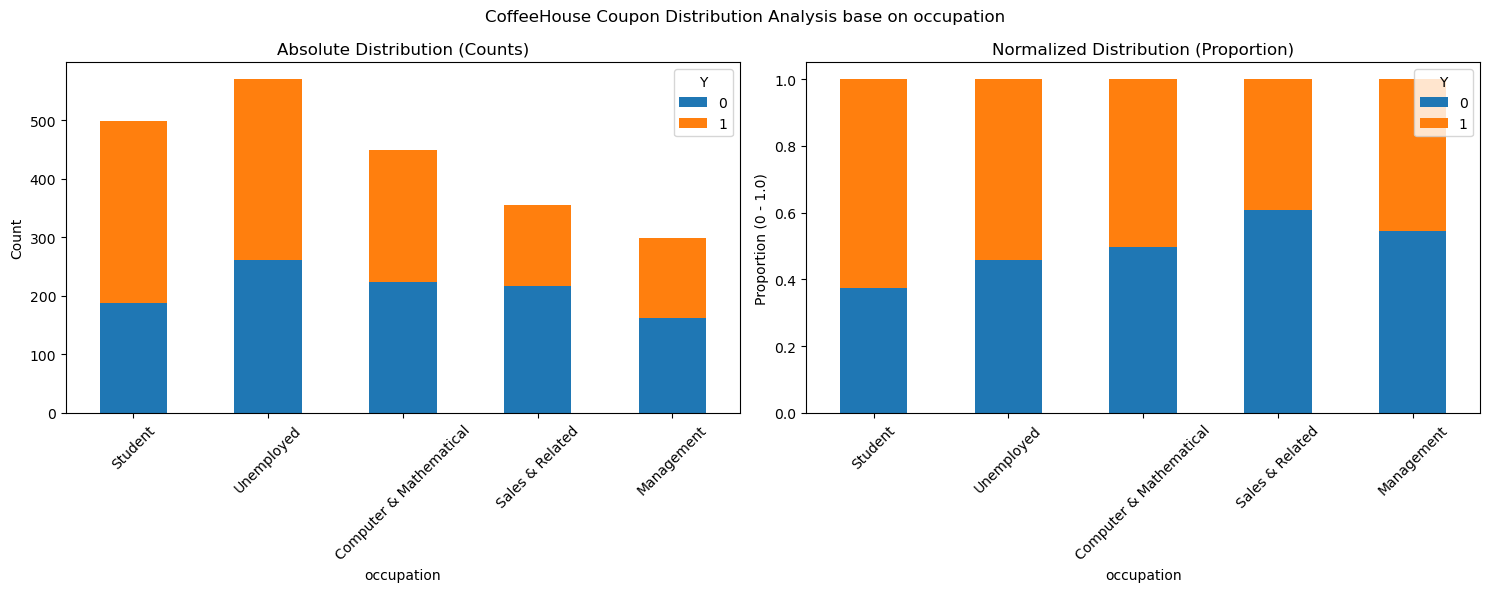

In [4512]:
# 1. Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 2. Plot Absolute Counts on the first subplot (left)
crosstab_occupation.plot(kind='bar', stacked=True, rot=0, ax=axes[0])
axes[0].set_title('Absolute Distribution (Counts)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', labelrotation=45)

# 3. Normalize data and Plot Percentages on the second subplot (right)
crosstab_norm = crosstab_occupation.div(crosstab_occupation.sum(1), axis=0)
crosstab_norm.plot(kind='bar', stacked=True, rot=0, ax=axes[1])
axes[1].set_title('Normalized Distribution (Proportion)')
axes[1].set_ylabel('Proportion (0 - 1.0)')
axes[1].tick_params(axis='x', labelrotation=45)

# Add a shared overall title

plt.suptitle('CoffeeHouse Coupon Distribution Analysis base on occupation')
plt.tight_layout()
plt.show()

In [4513]:
#compare acceptance rate by income group
coffee_df.groupby('income')['Y'].mean().sort_values(ascending=False)

income
$87500 - $99999     0.557196
Less than $12500    0.551948
$37500 - $49999     0.542373
$12500 - $24999     0.540404
$50000 - $62499     0.503650
$100000 or More     0.494382
$25000 - $37499     0.473438
$62500 - $74999     0.436364
$75000 - $87499     0.296610
Name: Y, dtype: float64

In [4514]:
# Check influcence of income group against coffeehouse coupon acceptance, and sorted by 'Y'=1 coupon counts.
crosstab_income = pd.crosstab(coffee_df['income'], coffee_df['Y']).sort_values(by=1, ascending=False)
# get the top 5
crosstab_income = crosstab_income.head()
print (f'crosstab_income is {crosstab_income}')

crosstab_income is Y                  0    1
income                   
$12500 - $24999  273  321
$37500 - $49999  270  320
$25000 - $37499  337  303
$50000 - $62499  272  276
$100000 or More  270  264


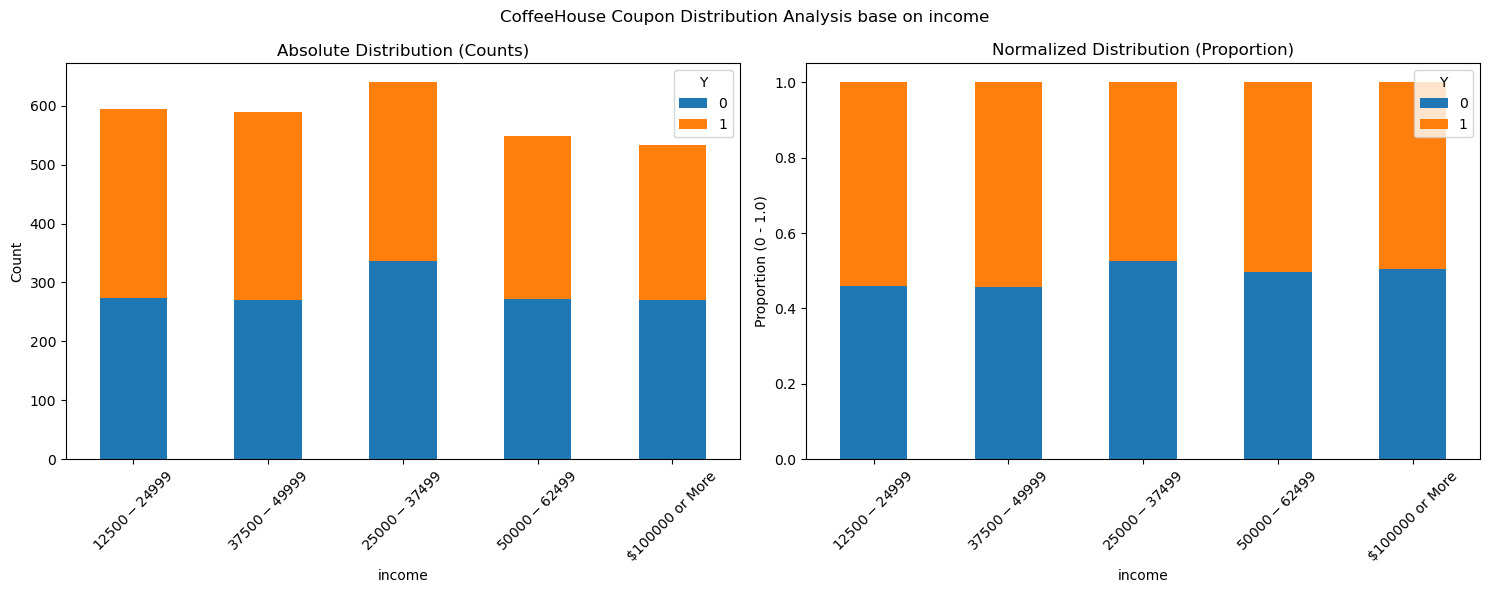

In [4515]:
# 1. Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 2. Plot Absolute Counts on the first subplot (left)
crosstab_income.plot(kind='bar', stacked=True, rot=0, ax=axes[0])
axes[0].set_title('Absolute Distribution (Counts)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', labelrotation=45)
# 3. Normalize data and Plot Percentages on the second subplot (right)
crosstab_norm = crosstab_income.div(crosstab_income.sum(1), axis=0)
crosstab_norm.plot(kind='bar', stacked=True, rot=0, ax=axes[1])
axes[1].set_title('Normalized Distribution (Proportion)')
axes[1].set_ylabel('Proportion (0 - 1.0)')
axes[1].tick_params(axis='x', labelrotation=45)

# Add a shared overall title
plt.suptitle('CoffeeHouse Coupon Distribution Analysis base on income')
plt.tight_layout()
plt.show()

In [4516]:
#compare acceptance rate by education group
coffee_df.groupby('education')['Y'].mean().sort_values(ascending=False)

education
Some High School                          0.607143
High School Graduate                      0.541219
Associates degree                         0.517143
Some college - no degree                  0.515682
Graduate degree (Masters or Doctorate)    0.510033
Bachelors degree                          0.462774
Name: Y, dtype: float64

In [4517]:
# Check influcence of education group against coffeehouse coupon acceptance, sort by 'Y'=1 coupon counts.
crosstab_education = pd.crosstab(coffee_df['education'], coffee_df['Y']).sort_values(by=1, ascending=False)
print (f'crosstab_education is {crosstab_education}')

crosstab_education is Y                                         0    1
education                                       
Some college - no degree                664  707
Bachelors degree                        736  634
Graduate degree (Masters or Doctorate)  293  305
Associates degree                       169  181
High School Graduate                    128  151
Some High School                         11   17


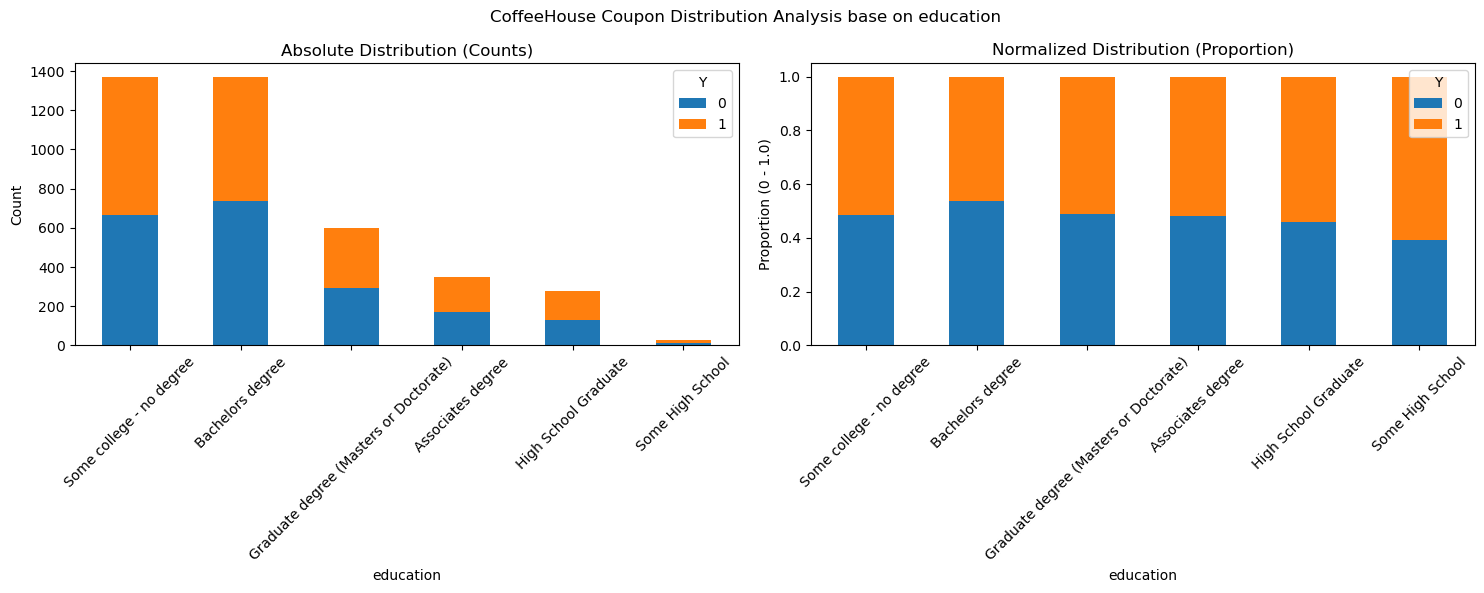

In [4518]:
# 1. Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 2. Plot Absolute Counts on the first subplot (left)
crosstab_education.plot(kind='bar', stacked=True, rot=0, ax=axes[0])
axes[0].set_title('Absolute Distribution (Counts)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', labelrotation=45)

# 3. Normalize data and Plot Percentages on the second subplot (right)
crosstab_norm = crosstab_education.div(crosstab_education.sum(1), axis=0)
crosstab_norm.plot(kind='bar', stacked=True, rot=0, ax=axes[1])
axes[1].set_title('Normalized Distribution (Proportion)')
axes[1].set_ylabel('Proportion (0 - 1.0)')
axes[1].tick_params(axis='x', labelrotation=45)

# Add a shared overall title
plt.suptitle('CoffeeHouse Coupon Distribution Analysis base on education')
plt.tight_layout()
plt.show()

In [4263]:
#compare acceptance rate by age group
coffee_df.groupby('age')['Y'].mean().sort_values(ascending=False)

age
below21    0.696774
21         0.524349
26         0.514828
46         0.513636
41         0.501538
31         0.476726
36         0.467662
50plus     0.420183
Name: Y, dtype: float64

In [4264]:
# Check influcence of age group against coffeehouse coupon acceptance, sorted by 'Y'=1 coupon counts.
crosstab_age = pd.crosstab(coffee_df['age'], coffee_df['Y'])
print (f'crosstab_age is {crosstab_age}')

crosstab_age is Y          0    1
age              
21       420  463
26       409  434
31       326  297
36       214  188
41       162  163
46       107  113
50plus   316  229
below21   47  108


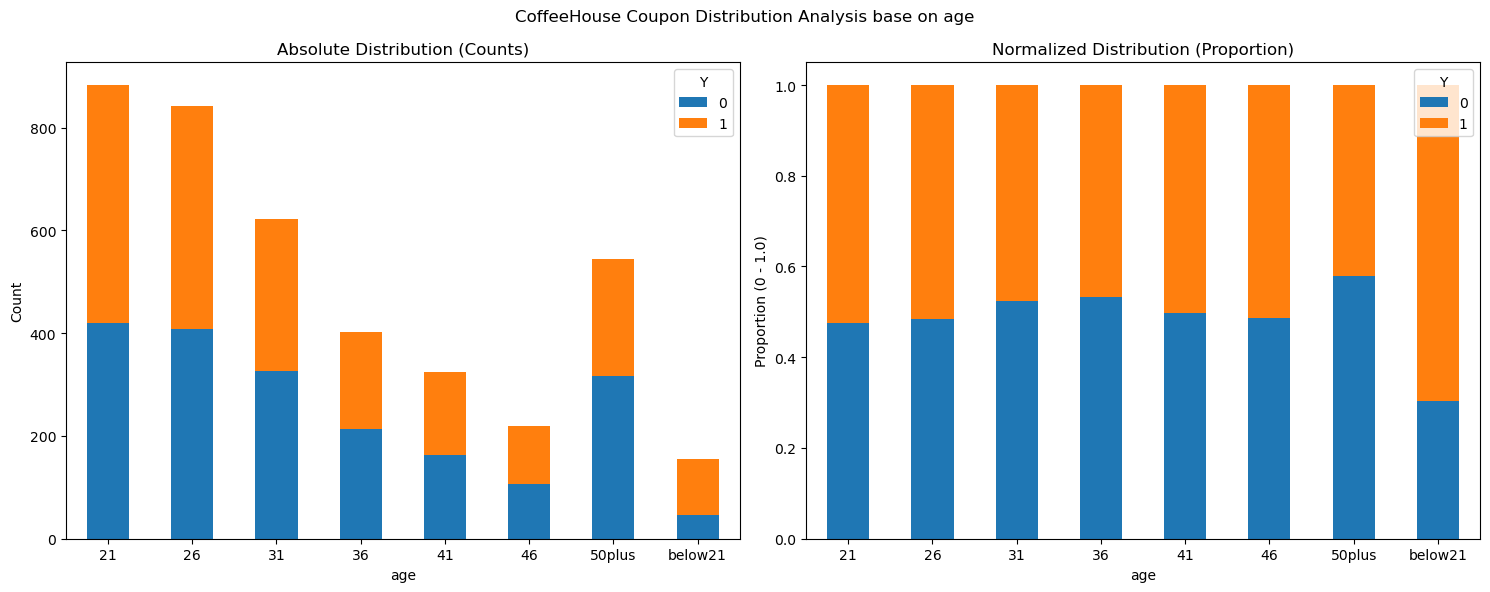

In [4265]:
# 1. Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 2. Plot Absolute Counts on the first subplot (left)
crosstab_age.plot(kind='bar', stacked=True, rot=0, ax=axes[0])
axes[0].set_title('Absolute Distribution (Counts)')
axes[0].set_ylabel('Count')

# 3. Normalize data and Plot Percentages on the second subplot (right)
crosstab_norm = crosstab_age.div(crosstab_age.sum(1), axis=0)
crosstab_norm.plot(kind='bar', stacked=True, rot=0, ax=axes[1])
axes[1].set_title('Normalized Distribution (Proportion)')
axes[1].set_ylabel('Proportion (0 - 1.0)')

# Add a shared overall title
plt.suptitle('CoffeeHouse Coupon Distribution Analysis base on age')
plt.tight_layout()
plt.show()

In [4266]:
#compare acceptance rate by time group
coffee_df.groupby('time')['Y'].mean().sort_values(ascending=False)

time
10AM    0.640712
2PM     0.547859
7AM     0.445783
10PM    0.424242
6PM     0.412626
Name: Y, dtype: float64

In [4267]:
# Check influcence of time against coffeehouse coupon acceptance, sorted by "Y"==1 counts.
crosstab_time = pd.crosstab(coffee_df['time'], coffee_df['Y']).sort_values(by=1, ascending=False)
print (f'crosstab_time is {crosstab_time}')

crosstab_time is Y       0    1
time          
10AM  323  576
6PM   642  451
2PM   359  435
7AM   506  407
10PM  171  126


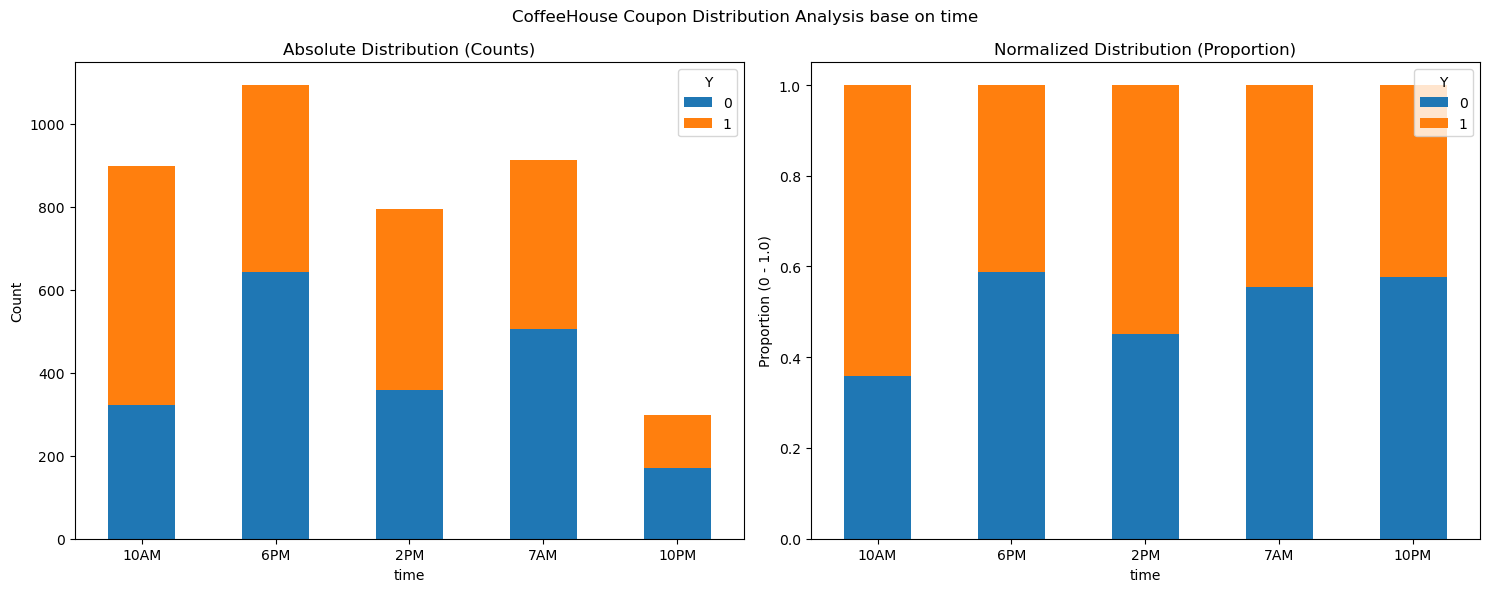

In [4268]:
# 1. Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 2. Plot Absolute Counts on the first subplot (left)
crosstab_time.plot(kind='bar', stacked=True, rot=0, ax=axes[0])
axes[0].set_title('Absolute Distribution (Counts)')
axes[0].set_ylabel('Count')

# 3. Normalize data and Plot Percentages on the second subplot (right)
crosstab_norm = crosstab_time.div(crosstab_time.sum(1), axis=0)
crosstab_norm.plot(kind='bar', stacked=True, rot=0, ax=axes[1])
axes[1].set_title('Normalized Distribution (Proportion)')
axes[1].set_ylabel('Proportion (0 - 1.0)')

# Add a shared overall title
plt.suptitle('CoffeeHouse Coupon Distribution Analysis base on time')
plt.tight_layout()
plt.show()

In [3745]:
# compare coupon acceptance rate by frequency of going to coffee house
coffee_df.groupby('CoffeeHouse')['Y'].mean().sort_values(ascending=False)

CoffeeHouse
4~8      0.685874
gt8      0.657895
1~3      0.647793
less1    0.481860
never    0.188781
Name: Y, dtype: float64

In [3746]:
# check influcence of coffeehouse frequencies against coffeehouse coupon acceptance counts
crosstab_coffeeHouseFreq = pd.crosstab(coffee_df['CoffeeHouse'], coffee_df['Y']).sort_values(by=1, ascending=False)
print (f'crosstab_coffeeHouseFreq is {crosstab_coffeeHouseFreq}')

crosstab_coffeeHouseFreq is Y              0    1
CoffeeHouse          
1~3          367  675
less1        557  518
4~8          169  369
gt8          117  225
never        752  175


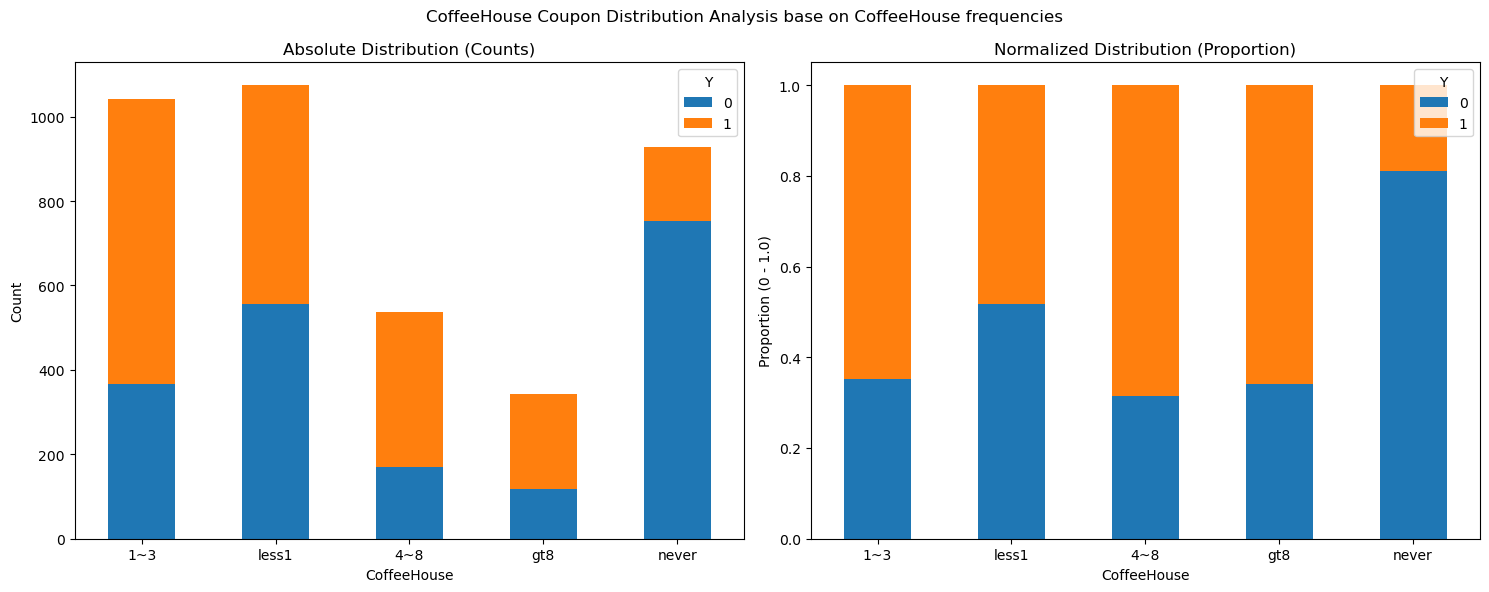

In [3748]:
# 1. Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 2. Plot Absolute Counts on the first subplot (left)
crosstab_coffeeHouseFreq.plot(kind='bar', stacked=True, rot=0, ax=axes[0])
axes[0].set_title('Absolute Distribution (Counts)')
axes[0].set_ylabel('Count')

# 3. Normalize data and Plot Percentages on the second subplot (right)
crosstab_norm = crosstab_coffeeHouseFreq.div(crosstab_coffeeHouseFreq.sum(1), axis=0)
crosstab_norm.plot(kind='bar', stacked=True, rot=0, ax=axes[1])
axes[1].set_title('Normalized Distribution (Proportion)')
axes[1].set_ylabel('Proportion (0 - 1.0)')

# Add a shared overall title
plt.suptitle('CoffeeHouse Coupon Distribution Analysis base on CoffeeHouse frequencies')
plt.tight_layout()
plt.show()

The data shows drivers that younger than 41 years old, student, Computer & Mathematical, higher education(some colledge or more), visit coffee house more often, in the morning hours 10AM, intent to accept coffee house coupon more. For drivers never go to coffee house, or some high school education, their coffeehouse coupon acceptance in terms of counts and rate are very low. Next step, explore more the acceptance rate with combination categories, ie, combine age with income, occupation...etc. And target the group mentioned above, for distribution of coffeeHouse coupon in counts and accpetance rate. Further, explore other coupons, ie, takeAway... and target distribution base on the similar analaysis for other coupons.